In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_dir = "/content/drive/MyDrive/FACE RECO/60 ẢNH"
validation_dir = "/content/drive/MyDrive/FACE RECO/60 ẢNH/BUI DANG KHOI"
img_width, img_height = 200,200
batch_size= 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
validation_datagen = ImageDataGenerator(
    rescale=1.0/255 # Only rescale for validation data
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False # Typically set to False for validation data
)

Found 0 images belonging to 0 classes.


In [ ]:
import matplotlib.pyplot as plt


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

num_classes = train_generator.num_classes
print(f"Số lượng lớp (người): {num_classes}")


model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])


epochs = 30
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator if validation_generator.samples > 0 else None
)


plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

In [ ]:
model.save('facerecog_model.h5')

Đang tải model từ: /content/facerecog_model.h5...
Tải model từ file thành công!


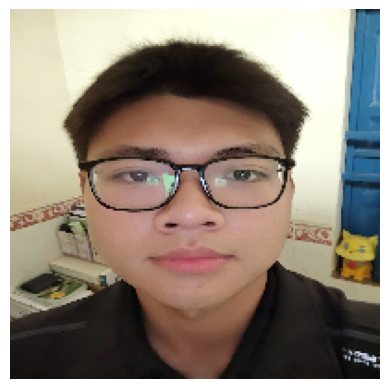

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
--- KẾT QUẢ DỰ ĐOÁN ---
Nhận diện: BUI DANG KHOI
Độ tin cậy: 98.07%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 1. Cấu hình đường dẫn từ file bên trái
model_path = '/content/facerecog_model.h5'
image_path = '/content/dggkh.jpg'
img_width, img_height = 200, 200

# 2. Load model từ file (với cơ chế dự phòng nếu file lỗi)
try:
    print(f"Đang tải model từ: {model_path}...")
    # Ép buộc load lại từ file theo yêu cầu của bạn
    current_model = load_model(model_path)
    print("Tải model từ file thành công!")
except Exception as e:
    print(f"Lỗi khi đọc file model: {e}")
    if 'model' in globals():
        print("Đang sử dụng model từ bộ nhớ tạm thời để thay thế...")
        current_model = model
    else:
        current_model = None

# 3. Tiến hành dự đoán nếu có model và ảnh
if current_model and os.path.exists(image_path):
    # Hiển thị ảnh
    img = load_img(image_path, target_size=(img_width, img_height))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Tiền xử lý
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Dự đoán
    preds = current_model.predict(img_array)
    prediction_idx = np.argmax(preds)
    confidence = np.max(preds) * 100

    # Lấy nhãn lớp
    try:
        # Ưu tiên lấy nhãn từ train_generator đã chạy trước đó
        class_labels = {v: k for k, v in train_generator.class_indices.items()}
        result_name = class_labels.get(prediction_idx, f"Lớp {prediction_idx}")
    except:
        result_name = f"Lớp {prediction_idx}"

    print(f"--- KẾT QUẢ DỰ ĐOÁN ---")
    print(f"Nhận diện: {result_name}")
    print(f"Độ tin cậy: {confidence:.2f}%")
else:
    print("Không thể thực hiện dự đoán. Vui lòng kiểm tra lại file model hoặc ảnh.")